# Whole-Image FLIM Simulation

Simulate a full 2-D fluorescence lifetime image by combining a binary
intensity mask with a multi-region ("multi-ROI") label mask, so different
regions of the image can carry independent simulator configurations. This
notebook walks through:

- loading an instrument response function (IRF) and computing the excitation
  frequency,
- choosing a mono- or bi-exponential decay model and configuring detector /
  noise settings,
- defining per-region simulator configs and assembling them with
  `FLIModelImageGenerator`,
- generating the full decay / fit / IRF cubes and per-pixel parameter maps,
  and
- visualizing the resulting lifetime, photon-count, and mono/bi-exponential
  maps, and probing a single pixel's decay trace.

In [1]:
## importing the modules required for this work
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# package from PyFli
from pyfli.io import DataOperations 
# from pyfli.simulator import PhotonCountSimulator
from pyfli.analytical_methods import AnalyticalHelpers
from pyfli.data_cc import Normalization
from pyfli.simulator import FLIImageGenerator, FLIModelImageGenerator
from pyfli.data_vnp import ColorProcessor, DataViewer
from pyfli.analysis.utils import random_true_pixel
from pyfli.data_text import MessageDisplay



In [2]:
IRF_PATH = "<select file/folder path>"

In [3]:
loader = DataOperations(irf_path=IRF_PATH)
irf_data = loader.load_irf()
print(f'IRF data shape is: {irf_data.shape}')

gate_delay = 12.5/irf_data.shape[2]
num_gates = irf_data.shape[2]
freq = AnalyticalHelpers(laser_period = 12.5, gate_delay=gate_delay, num_gate = num_gates).freq_computation()
freq_hz = freq[1] * 1e6
print(f'the frequency use is: {freq[1]} MHz')

INFO:pyfli:Initiating IRF load from: <select file/folder path>


IRF data shape is: (512, 512, 256)
the frequency use is: 80.0 MHz


In [4]:
# select the type of decay model to simulate
MODEL_TYPE = "mono-exponential"

if MODEL_TYPE == "bi-exponential":
    mono_fraction = 0.0
elif MODEL_TYPE == "mono-exponential":
    mono_fraction = 1.0

In [5]:
img_ = plt.imread('<select file/folder path>')
b_bool_mask = (img_[..., 0] > 0) if img_.ndim == 3 else (img_ > 0)

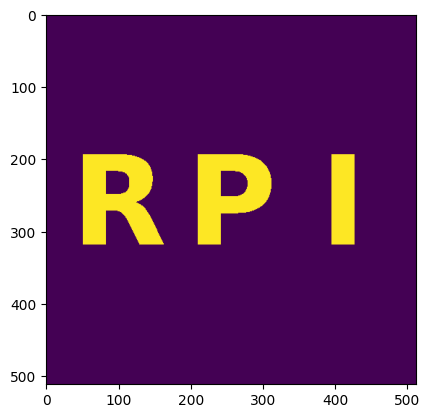

In [6]:
plt.rcParams['axes.grid'] = False
plt.imshow(b_bool_mask)

In [7]:
print(b_bool_mask.dtype, b_bool_mask.shape, b_bool_mask.sum(), "True pixels")
# dtype: bool,  shape: (H, W),  e.g. 12843 True pixels

bool (512, 512) 20976 True pixels


In [8]:
# Your constant, default configuration
BASE_CONFIG = {
    # Modular Noise
    "jitter":        [True, False][0],   # temporal jitter shift
    "dcr_on":        [True, False][0],   # Dark Count Rate (thermal background)
    "poisson":       [True, False][0],   # Shot noise — Macro_sim only
    "qe_on":         [True, False][0],   # Quantum efficiency scaling
    "read_noise_on": [True, False][0],   # Gaussian read noise — Macro_sim / ICCD only

    # Sensor
    "sensor_type": "PHOTON_COUNTER",     # "ICCD" (Macro_sim) | "PHOTON_COUNTER" (TCSPC_sim)
    # "bit":          10,                  # ADC bit depth for ICCD; TCSPC defaults to 16 if unset
    "dcr":          0.08,                # Mean dark counts per bin
    "laser_feq":    80,                  # Laser repetition rate (MHz) → period = 12.5 ns
    "round_on":    [True, False][0],     # Round photon counts to integers — Macro_sim only
    "clip_on":     [True, False][0],     # Clip at bit-depth ceiling — Macro_sim: max_adc_val; TCSPC: max_bin_count

    # Fluorescence Physics (FLI / FRET)
    "tau2":          (1, 1),           # τ₂ ~ TruncNormal(mu=1 ns, sigma=0.5 ns)
    "tau2_dist":     "beta",             # if dist "beta" or "normal" (default)
    "efficiency":    (1, 1),             # FRET efficiency E ~ Beta(2, 5)  → [0.1, 1.0]
    "A1_fraction":   (1, 1),             # Amplitude fraction A₁ ~ Beta(2, 5) → [0.05, 0.95]
    "photo_count":   (4, 4),             # Peak intensity ~ Beta(2, 5) × max_adc — Macro_sim only
    "mono_fraction":  mono_fraction,                # Fraction of pixels forced mono-exponential (0.0 = all bi-exp)
    "n_cycles":      1_000_000,            # Accumulation cycles — TCSPC_sim only
}


def get_config(**kwargs):
    # creating a config by overriding defaults with specific test parameters."""
    config = BASE_CONFIG.copy()
    config.update(kwargs)
    return config

pn = [False, True][1]
jit = [False, True][1]

# ROI0 = {}
# ROI1 = get_config(poisson=pn, jitter=jit, tau2 = (0.6, 0.01))
# ROI2 = get_config(poisson=pn, jitter=jit, tau2 = (1, 0.01))
# ROI3 = get_config(poisson=pn, jitter=jit, tau2 = (1.5, 0.01))

ROI0 = {}
ROI1 = get_config(poisson=pn, jitter=jit,  tau2_beta_range = (0.05, 0.6),)
ROI2 = get_config(poisson=pn, jitter=jit,  tau2_beta_range = (0.05, 1),)
ROI3 = get_config(poisson=pn, jitter=jit,  tau2_beta_range = (0.05, 1.5),)

img_intensity = "<select file/folder path>"
img_mask = '<select file/folder path>'


simulated_img = FLIModelImageGenerator(irf_data=irf_data, 
                                  intensity_image_path=img_intensity,
                                  roi_mask_path=img_mask, 
                                  roi_params=[ROI0, ROI1, ROI2,ROI3], 
                                  method="PHOTON_COUNTER", 
                                  verbose=True,
                                  bool_mask = b_bool_mask)

In [9]:
gt_data = simulated_img.generate_image()

Generating PHOTON_COUNTER FLI Image [512x512x256]...


In [10]:
jet_m = ColorProcessor().lowest_zero('jet')
plasma_m =ColorProcessor().lowest_zero('plasma')
magma_m = ColorProcessor().lowest_zero('magma')

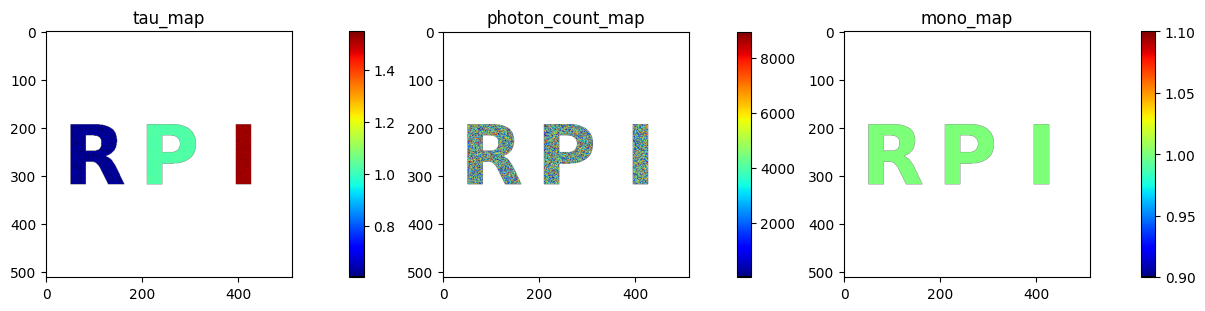

In [11]:
res = gt_data['results']['maps']
if MODEL_TYPE == "bi-exponential":
    data_list = [res['tau1_map'], res['tau2_map'], res['alpha1_map'], res['A1_map'], res['A2_map'], res['fret_efficiency_map'], res['tau_mean_map'], res['photon_count_map'], res['mono_map']]
    data_names = ['tau1_map', 'tau2_map', 'alpha1_map', 'A1_map', 'A2_map', 'fret_efficiency_map', 'tau_mean_map', 'photon_count_map', 'mono_map']
    rows = 3
    fig_size = (13,9)
else:
    data_list = [res['tau_map'], res['photon_count_map'], res['mono_map']]
    data_names = ['tau_map', 'photon_count_map', 'mono_map']
    rows = 1
    fig_size = (12,3)

cmaps = [jet_m]*len(data_list)
# v_ranges = [(0,1),(0,2),(0, 2),(0,1)]
# cmaps = None
v_ranges = None
px = None

if px is None:
    cols = int(len(data_list)/rows)
else:
    cols = int(len(data_list)/rows)+1


_ = DataViewer().display_data(data_list, structure= (rows, cols), coord=px, data_names=data_names,
                     cmaps=cmaps, v_ranges=v_ranges, figsize=fig_size, normalize=False, yscale = 'linear')

In [12]:
sim_decay = gt_data['raw_data']['decay']
sim_irf = gt_data['raw_data']['irf']

the non-zero pixel selected for probing is (278, 59)


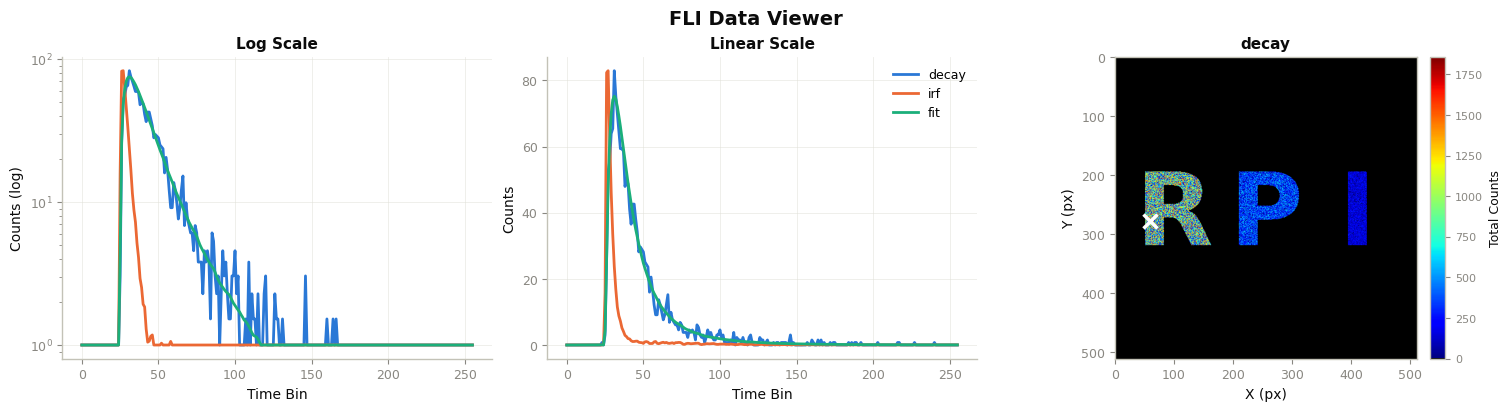

INFO:pyfli:
  Pixel (278, 59)
  ─────────────────────
  A         2240.0266
  α         —
  τ₁        0.6399
  τ₂        —
  R²        —
  Red.χ²    —
  Raw.χ²    —
  v-shift   —
  h-shift   —
  ─────────────────────



In [21]:
x,y = random_true_pixel(b_bool_mask)
TRs = gt_data['results']['TR_maps']
maps = gt_data['results']['maps']
print(f'the non-zero pixel selected for probing is ({x}, {y})')
irf_norm= Normalization(sim_irf).norm_scale(sim_decay)
DataViewer().plot_fli_px(data_list=[sim_decay, irf_norm, TRs['fit_map'], TRs['residual_map']],
                         pixel=(x,y),
                         mode=[0,1,2],
                         mode2=[1],
                         names = ['decay', 'irf', 'fit'],
                         cmap = jet_m)
px_params = MessageDisplay().get_pixel_summary(data_maps=maps, px=(x,y))